<a href="https://colab.research.google.com/github/hegde-shashi/arecanut_proejct/blob/main/betelnet_grouping/betelnut_grouping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
!pip install keras-tuner tensorflow tensorboard

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import keras

In [21]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
CHANNELS = 3
EPOCHS = 50

In [22]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Arecanut_project/dataset/Betelnet',
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 8458 files belonging to 5 classes.


In [23]:
dataset.class_names

['Bette', 'Chaali', 'Chaali_2nd', 'Maani', 'laddu']

In [24]:
len(dataset)

133

In [25]:
image_batch_display, label_batch_display = next(iter(dataset))

In [26]:
print(image_batch_display.shape)
print(label_batch_display.numpy())

(64, 224, 224, 3)
[4 1 1 1 1 3 3 4 2 4 1 1 2 1 3 2 1 2 1 1 4 0 2 1 3 3 3 2 4 1 2 1 2 0 3 2 1
 0 0 4 4 4 3 1 2 0 1 1 3 0 1 4 1 1 1 3 0 4 2 4 0 3 1 2]


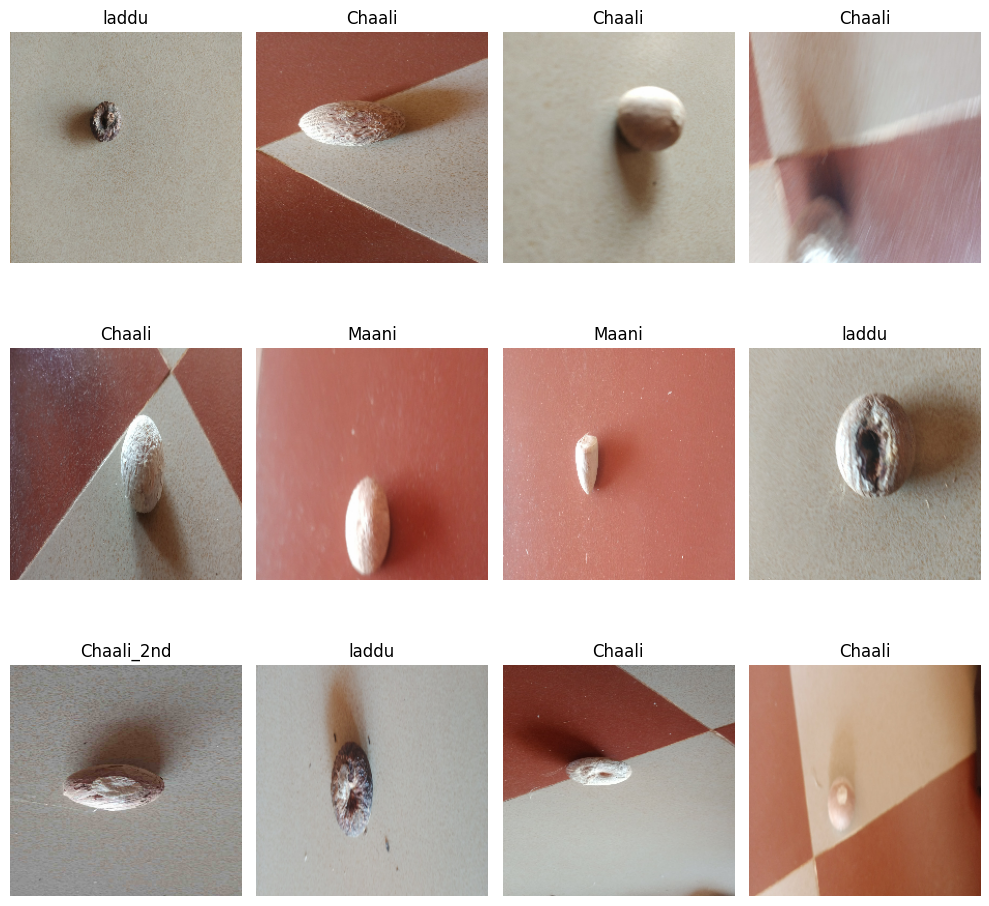

In [27]:
plt.figure(figsize=(10,10))
for i in range(12):
  ax = plt.subplot(3, 4, i+1)
  plt.imshow(image_batch_display[i].numpy().astype('uint8'))
  plt.title(dataset.class_names[label_batch_display[i]])
  plt.axis("off")
plt.tight_layout()

In [28]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

print(f"Total batches: {len(dataset)}")
print(f"Training batches: {train_size}")
print(f"Validation batches: {val_size}")
print(f"Test batches: {test_size}")

Total batches: 133
Training batches: 106
Validation batches: 13
Test batches: 14


### Optimize Dataset Performance
We will use `cache()` and `prefetch()` to optimize the performance of our dataset. `cache()` keeps images in memory after the first epoch, and `prefetch()` overlaps data preprocessing and model execution.

In [29]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)


In [30]:
print("length of train data : ", len(train_ds))
print("length of test data: ", len(val_ds))
print("length of validation data : ", len(test_ds))

length of train data :  106
length of test data:  13
length of validation data :  14


In [31]:
train_ds_prefetch = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_prefetch = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_prefetch = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [32]:
def build_cnn_model(hp):
  inputs = Input(shape=(224,224,3))

  x = inputs

  #Block 1
  x = Conv2D(
      filters = hp.Int('filter_1', 32, 64, step=16),
      kernel_size = 3,
      activation = 'relu',
      padding = 'same',
      kernel_regularizer = l2(1e-4) # Corrected typo here
  ) (x)
  x = BatchNormalization() (x)
  x = MaxPooling2D() (x)

  #Block 2
  x = Conv2D(
      filters = hp.Int('filter_2', 128, 256, step=32),
      kernel_size = 3,
      activation = 'relu',
      padding = 'same',
      kernel_regularizer = l2(1e-4) # Corrected typo here
  ) (x)
  x = BatchNormalization() (x)
  x = MaxPooling2D() (x)

  x = Flatten() (x)

  x = Dense(
      units = hp.Int('dense_units', 128, 256, step=128),
      activation = 'relu'
  )(x) # Corrected: Apply Dense layer to the tensor x

  x = Dropout(hp.Float('dropout_rate', 0.4, 0.6 ,step=0.1)) (x) # Renamed hyperparameter to 'dropout_rate'

  outputs = Dense(len(dataset.class_names), activation='softmax') (x) # Changed activation to softmax

  model = Model(inputs=inputs, outputs=outputs)

  model.compile(
      optimizer = Adam(hp.Float('lr', 1e-4, 1e-2, sampling='log')),
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )

  return model

In [33]:
tuner = kt.RandomSearch(
    build_cnn_model,
    objective = 'val_accuracy',
    max_trials = 10,
    directory = 'betelnet_tuning',
    project_name = 'cnn_quality_grading',
)

In [ ]:
tuner.search(
    train_ds_prefetch,
    validation_data = val_ds_prefetch,
    epochs = 15
)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
48                |48                |filter_1
128               |128               |filter_2
128               |128               |dense_units
0.4               |0.4               |dropout_rate
0.00013468        |0.00013468        |lr

Epoch 1/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 726s 7s/step - accuracy: 0.4738 - loss: 2.2698 - val_accuracy: 0.3401 - val_loss: 2.4606
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 690s 7s/step - accuracy: 0.5509 - loss: 1.1362 - val_accuracy: 0.5841 - val_loss: 1.1071
Epoch 3/15
 22/106 ━━━━━━━━━━━━━━━━━━━━ 8:53 6s/step - accuracy: 0.6042 - loss: 1.0684

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1),
    ModelCheckpoint('best_betelnet_cnn.h5', save_best_only=True)
]

history = best_model.fit(
    train_ds_prefetch,
    validation_data = val_ds_prefetch,
    epochs = EPOCHS,
    callbacks = callbacks,
    verbose = 1
)